<a href="https://colab.research.google.com/github/sydneythompson11/Advanced-ML/blob/main/HW_6_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CNN Assignment — Fashion MNIST Image Classification

## Imports & Setup

In [1]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 6.1 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.datasets import fashion_mnist

import optuna

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Class names for Fashion MNIST
CLASS_NAMES = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print('TF version:', tf.__version__)

TF version: 2.20.0


## Load Data & Visualize

Fashion MNIST is loaded directly from Keras using same API from previous notebooks.
It contains 60,000 training and 10,000 test grayscale images (28×28) across 10 clothing categories.

In [3]:
# Load data — same pattern as Inclass_05_19.ipynb
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist.load_data()

print('Full train shape:', X_train_full.shape)
print('Test shape:      ', X_test.shape)
print('Pixel range:     ', X_train_full.min(), '-', X_train_full.max())
print('Classes:', CLASS_NAMES)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Full train shape: (60000, 28, 28)
Test shape:       (10000, 28, 28)
Pixel range:      0 - 255
Classes: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


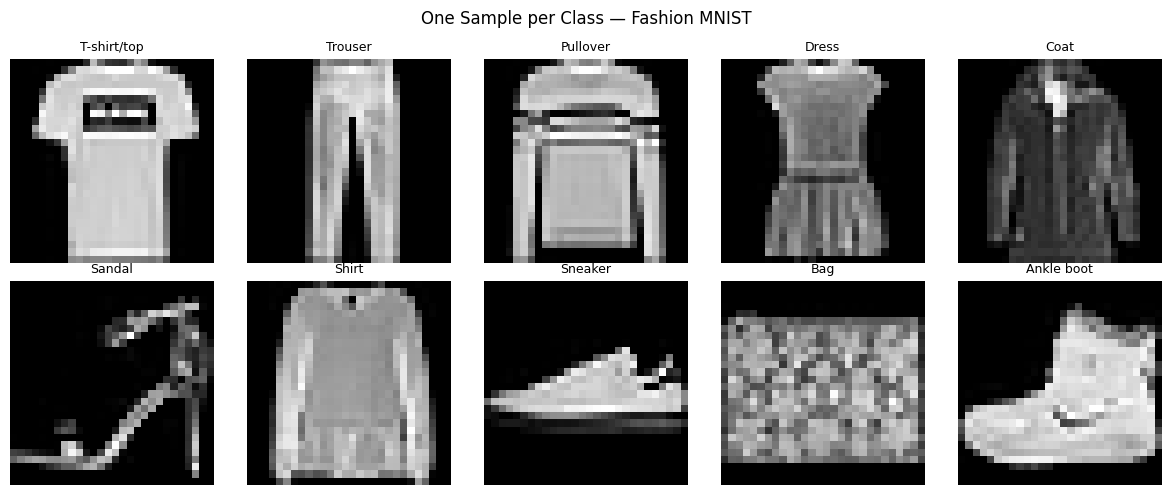

In [4]:
# Visualize sample images from each class (mirrors Inclass_05_19 visualization)
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for cls_idx, ax in enumerate(axes.flat):
    sample_idx = np.where(y_train_full == cls_idx)[0][0]
    ax.imshow(X_train_full[sample_idx], cmap='gray')
    ax.set_title(CLASS_NAMES[cls_idx], fontsize=9)
    ax.axis('off')
plt.suptitle('One Sample per Class — Fashion MNIST', fontsize=12)
plt.tight_layout()
plt.show()

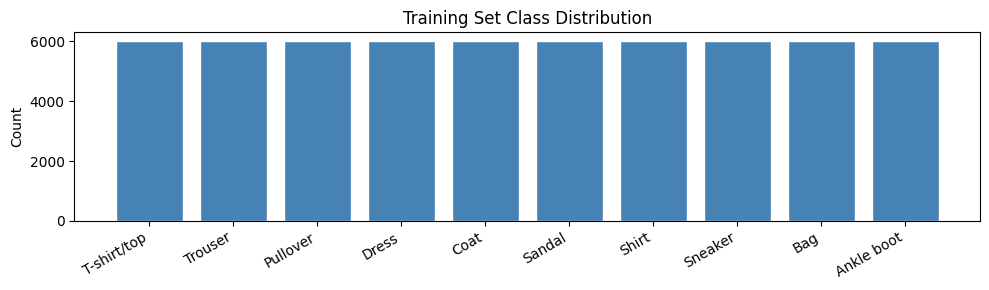

Balanced dataset — each class has 6000 samples


In [5]:
# Class distribution
unique, counts = np.unique(y_train_full, return_counts=True)
plt.figure(figsize=(10, 3))
plt.bar([CLASS_NAMES[i] for i in unique], counts, color='steelblue', edgecolor='white')
plt.title('Training Set Class Distribution')
plt.xticks(rotation=30, ha='right')
plt.ylabel('Count')
plt.tight_layout()
plt.show()
print('Balanced dataset — each class has', counts[0], 'samples')

## Preprocessing

In [6]:
# Normalize to [0, 1]
X_train_full = X_train_full.astype('float32') / 255.0
X_test       = X_test.astype('float32') / 255.0

# Add channel dimension for Conv2D
X_train_full = X_train_full[..., np.newaxis]  # (60000, 28, 28, 1)
X_test       = X_test[..., np.newaxis]         # (10000, 28, 28, 1)

# Carve out validation set (last 10k of training)
X_val,   y_val   = X_train_full[-10000:], y_train_full[-10000:]
X_train, y_train = X_train_full[:-10000], y_train_full[:-10000]

print(f'Train : {X_train.shape}  |  Val: {X_val.shape}  |  Test: {X_test.shape}')
print(f'Pixel range after normalization: {X_train.min():.1f} – {X_train.max():.1f}')

Train : (50000, 28, 28, 1)  |  Val: (10000, 28, 28, 1)  |  Test: (10000, 28, 28, 1)
Pixel range after normalization: 0.0 – 1.0


## Helper Functions

In [7]:
def plot_history(history, title='Training History'):
    """Plot loss and accuracy curves — reused from Inclass_05_19 pattern."""
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].plot(history.history['loss'],     label='Train Loss')
    axes[0].plot(history.history['val_loss'], label='Val Loss')
    axes[0].set_title(f'{title} — Loss')
    axes[0].set_xlabel('Epoch'); axes[0].legend()

    axes[1].plot(history.history['accuracy'],     label='Train Acc')
    axes[1].plot(history.history['val_accuracy'], label='Val Acc')
    axes[1].set_title(f'{title} — Accuracy')
    axes[1].set_xlabel('Epoch'); axes[1].legend()
    plt.tight_layout(); plt.show()


def evaluate_model(model, X, y, label='Validation', show_cm=False):
    """Print accuracy + classification report. Optionally show confusion matrix."""
    y_pred = np.argmax(model.predict(X, verbose=0), axis=1)
    acc = np.mean(y_pred == y)
    print(f'\n=== {label} Evaluation ===')
    print(f'Accuracy: {acc:.4f}')
    print(classification_report(y, y_pred, target_names=CLASS_NAMES))
    if show_cm:
        cm = confusion_matrix(y, y_pred)
        fig, ax = plt.subplots(figsize=(9, 7))
        ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(
            ax=ax, colorbar=False, xticks_rotation='vertical')
        ax.set_title(f'{label} — Confusion Matrix')
        plt.tight_layout(); plt.show()
    return acc


results = {}  # {model_name: val_accuracy}

## Baseline CNN


In [8]:
def build_baseline():
    model = models.Sequential([
        # Block 1
        layers.Conv2D(32, (3, 3), activation='relu', padding='same',
                      input_shape=(28, 28, 1)),
        layers.MaxPooling2D((2, 2)),
        # Block 2
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        # Classifier head
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(10, activation='softmax')
    ], name='baseline')
    model.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

baseline = build_baseline()
baseline.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,642 (1.61 MB)

 Trainable params: 421,642 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

Stopped at epoch 5


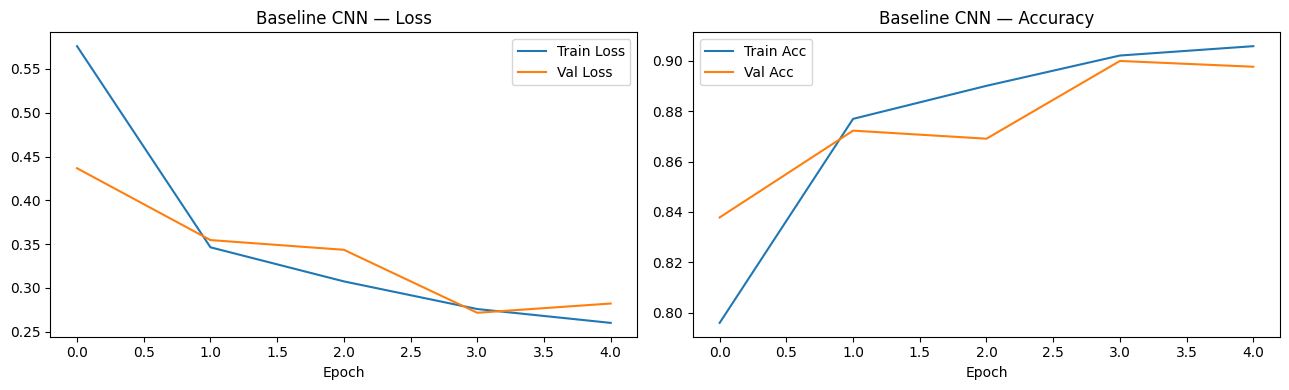


=== Baseline — Validation Evaluation ===
Accuracy: 0.9000
              precision    recall  f1-score   support

 T-shirt/top       0.84      0.89      0.86      1023
     Trouser       0.99      0.97      0.98       988
    Pullover       0.88      0.79      0.83      1008
       Dress       0.91      0.93      0.92      1021
        Coat       0.80      0.86      0.83      1050
      Sandal       0.99      0.95      0.97       996
       Shirt       0.75      0.70      0.72       970
     Sneaker       0.93      0.96      0.95       955
         Bag       0.98      0.98      0.98       968
  Ankle boot       0.96      0.97      0.96      1021

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



In [9]:
es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history_baseline = baseline.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=5,
    batch_size=256,
    callbacks=[es],
    verbose=0
)
print(f'Stopped at epoch {len(history_baseline.history["loss"])}')
plot_history(history_baseline, 'Baseline CNN')
acc = evaluate_model(baseline, X_val, y_val, 'Baseline — Validation')
results['Baseline'] = acc

### Baseline Analysis

**What to observe in the curves above:**
- If train accuracy climbs well above val accuracy, the model is overfitting.
- If both curves plateau early and stay low, the model is underfitting.
- The baseline gives us a reference point.

## Experiment 1 — Number of Conv Blocks (One Factor at a Time)

**Question:** Does adding more convolutional blocks improve feature extraction?

In [10]:
def build_depth_cnn(n_blocks):
    """CNN with variable number of Conv+Pool blocks."""
    inp = keras.Input(shape=(28, 28, 1))
    x = inp
    filters = 32
    for i in range(n_blocks):
        x = layers.Conv2D(filters, (3, 3), activation='relu', padding='same')(x)
        x = layers.MaxPooling2D((2, 2))(x)
        filters = min(filters * 2, 128)  # double filters each block, cap at 128
    x = layers.Flatten()(x)
    x = layers.Dense(128, activation='relu')(x)
    out = layers.Dense(10, activation='softmax')(x)
    model = keras.Model(inp, out)
    model.compile(optimizer=keras.optimizers.Adam(1e-3),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

depth_configs = {'1 Block': 1, '2 Blocks (Baseline)': 2, '3 Blocks': 3}
depth_histories = {}

for name, n_blocks in depth_configs.items():
    tf.random.set_seed(42)
    m = build_depth_cnn(n_blocks)
    es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    h = m.fit(X_train, y_train, validation_data=(X_val, y_val),
              epochs=30, batch_size=128, callbacks=[es], verbose=0)
    depth_histories[name] = h
    acc = evaluate_model(m, X_val, y_val, name)
    results[name] = acc


=== 1 Block Evaluation ===
Accuracy: 0.9107
              precision    recall  f1-score   support

 T-shirt/top       0.90      0.83      0.86      1023
     Trouser       0.99      0.98      0.99       988
    Pullover       0.92      0.80      0.86      1008
       Dress       0.91      0.93      0.92      1021
        Coat       0.86      0.87      0.87      1050
      Sandal       0.99      0.97      0.98       996
       Shirt       0.70      0.82      0.76       970
     Sneaker       0.92      0.99      0.95       955
         Bag       0.97      0.98      0.98       968
  Ankle boot       0.99      0.94      0.96      1021

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000


=== 2 Blocks (Baseline) Evaluation ===
Accuracy: 0.9156
              precision    recall  f1-score   support

 T-shirt/top       0.84      0.91      0.87      1023
     Trouser       0.99      0

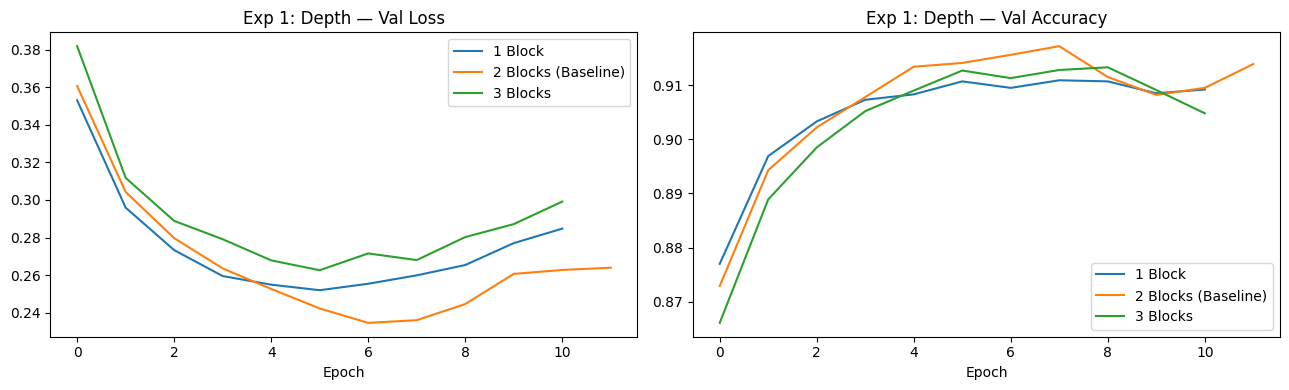

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for name, h in depth_histories.items():
    axes[0].plot(h.history['val_loss'],     label=name)
    axes[1].plot(h.history['val_accuracy'], label=name)
axes[0].set_title('Exp 1: Depth — Val Loss')
axes[1].set_title('Exp 1: Depth — Val Accuracy')
for ax in axes: ax.set_xlabel('Epoch'); ax.legend()
plt.tight_layout(); plt.show()

### Experiment 1 Analysis

**What to look for:**
- 1 block likely underfits, meaning there is not enough spatial feature hierarchy for 10 clothing classes.
- 2 blocks (baseline) should perform well. These images don't need many pooling steps before spatial info is lost.
- 3 blocks may help slightly but risks reducing the feature map to very small spatial dimensions and can hurt performance.

**Tradeoff:** More blocks = more parameters and longer training, but diminishing returns on small images. 2-3 blocks seems reasonable.

## Experiment 2 — Number of Filters (One Factor at a Time)

**Question:** Does increasing filter count improve the model's ability to learn features?

In [ ]:
def build_filter_cnn(base_filters):
    model = models.Sequential([
        layers.Conv2D(base_filters, (3,3), activation='relu', padding='same', input_shape=(28,28,1)),
        layers.MaxPooling2D((2,2)),
        layers.Conv2D(base_filters*2, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    model.compile(optimizer=keras.optimizers.Adam(1e-3),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

filter_configs = {'16→32 Filters': 16, '32→64 (Baseline)': 32, '64→128 Filters': 64}
filter_histories = {}

for name, base_f in filter_configs.items():
    tf.random.set_seed(42)
    m = build_filter_cnn(base_f)
    es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    h = m.fit(X_train, y_train, validation_data=(X_val, y_val),
              epochs=30, batch_size=128, callbacks=[es], verbose=0)
    filter_histories[name] = h
    acc = evaluate_model(m, X_val, y_val, name)
    results[name] = acc

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for name, h in filter_histories.items():
    axes[0].plot(h.history['val_loss'],     label=name)
    axes[1].plot(h.history['val_accuracy'], label=name)
axes[0].set_title('Exp 2: Filters — Val Loss')
axes[1].set_title('Exp 2: Filters — Val Accuracy')
for ax in axes: ax.set_xlabel('Epoch'); ax.legend()
plt.tight_layout(); plt.show()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



=== 16→32 Filters Evaluation ===
Accuracy: 0.9163
              precision    recall  f1-score   support

 T-shirt/top       0.86      0.89      0.88      1023
     Trouser       0.99      0.98      0.98       988
    Pullover       0.92      0.83      0.87      1008
       Dress       0.88      0.95      0.91      1021
        Coat       0.87      0.86      0.87      1050
      Sandal       0.98      0.97      0.98       996
       Shirt       0.78      0.76      0.77       970
     Sneaker       0.94      0.98      0.96       955
         Bag       0.96      0.99      0.97       968
  Ankle boot       0.98      0.96      0.97      1021

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000



/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### Experiment 2 Analysis

**What to look for:**
- Fewer filters (16→32) may underfit — not enough capacity to distinguish 10 clothing categories.
- More filters (64→128) should improve accuracy but increases parameter count significantly.
- Watch for the train/val gap widening with more filters — a sign of overfitting that motivates dropout.

**Tradeoff:** More filters = more expressive model but more parameters, longer training, and higher overfitting risk.
This experiment motivates adding dropout in Experiment 3.

## Experiment 3 — Dropout Regularization (One Factor at a Time)

**Question:** Does dropout reduce overfitting and improve generalization?

In [ ]:
def build_dropout_cnn(dropout_rate):
    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(28,28,1)),
        layers.MaxPooling2D((2,2)),
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(dropout_rate),
        layers.Dense(10, activation='softmax')
    ])
    model.compile(optimizer=keras.optimizers.Adam(1e-3),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

dropout_configs = {'No Dropout (0.0)': 0.0, 'Light (0.25)': 0.25,
                   'Moderate (0.4)': 0.4, 'Heavy (0.5)': 0.5}
dropout_histories = {}

for name, rate in dropout_configs.items():
    tf.random.set_seed(42)
    m = build_dropout_cnn(rate)
    es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    h = m.fit(X_train, y_train, validation_data=(X_val, y_val),
              epochs=30, batch_size=128, callbacks=[es], verbose=0)
    dropout_histories[name] = h
    acc = evaluate_model(m, X_val, y_val, name)
    results[name] = acc

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for name, h in dropout_histories.items():
    axes[0].plot(h.history['loss'],         label=name)
    axes[1].plot(h.history['val_accuracy'], label=name)
axes[0].set_title('Exp 3: Dropout — Train Loss')
axes[1].set_title('Exp 3: Dropout — Val Accuracy')
for ax in axes: ax.set_xlabel('Epoch'); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

### Experiment 3 Analysis

**What to look for:**
- No Dropout: train loss drops fast, val accuracy may plateau, which can lead to overfitting.
- Light (0.25): small regularization effect; train/val curves should be closer together.
- Moderate (0.4): stronger regularization; may slow convergence but better generalization.
- Heavy (0.5): may hurt performance if the model doesn't have enough capacity.

Dropout is the most impactful single regularization choice for CNNs.
The train/val accuracy gap is the clearest signal of overfitting.

## Experiment 4 — Batch Normalization (One Factor at a Time)

**Question:** Does adding BatchNorm after conv layers stabilize training and improve accuracy?

In [ ]:
def build_bn_cnn(use_bn):
    inp = keras.Input(shape=(28, 28, 1))
    x = layers.Conv2D(32, (3,3), padding='same')(inp)
    if use_bn: x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2,2))(x)

    x = layers.Conv2D(64, (3,3), padding='same')(x)
    if use_bn: x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2,2))(x)

    x = layers.Flatten()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(10, activation='softmax')(x)
    model = keras.Model(inp, out)
    model.compile(optimizer=keras.optimizers.Adam(1e-3),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

bn_histories = {}
for use_bn, label in [(False, 'No BatchNorm'), (True, 'With BatchNorm')]:
    tf.random.set_seed(42)
    m = build_bn_cnn(use_bn)
    es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    h = m.fit(X_train, y_train, validation_data=(X_val, y_val),
              epochs=30, batch_size=128, callbacks=[es], verbose=0)
    bn_histories[label] = h
    acc = evaluate_model(m, X_val, y_val, label)
    results[label] = acc

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for name, h in bn_histories.items():
    axes[0].plot(h.history['val_loss'],     label=name)
    axes[1].plot(h.history['val_accuracy'], label=name)
axes[0].set_title('Exp 4: BatchNorm — Val Loss')
axes[1].set_title('Exp 4: BatchNorm — Val Accuracy')
for ax in axes: ax.set_xlabel('Epoch'); ax.legend()
plt.tight_layout(); plt.show()

### Experiment 4 Analysis

**What to look for:**
- BatchNorm typically makes training curves smoother and allows faster convergence.
- It acts as a mild regularizer, which can reduce the train and validation gap.
- On small datasets like Fashion MNIST, the benefit is good.

**Tradeoff:** BatchNorm adds parameters and slightly increases inference time, but the training stability benefit usually justifies it.

## Experiment 5 — Data Augmentation

**Question:** Does augmenting training images reduce overfitting and improve generalization?

In [ ]:
# Augmentation layer (applied only during training)
data_augmentation = models.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
], name='augmentation')

def build_augmented_cnn(use_augmentation):
    inp = keras.Input(shape=(28, 28, 1))
    x = data_augmentation(inp) if use_augmentation else inp
    x = layers.Conv2D(32, (3,3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Conv2D(64, (3,3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Flatten()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(10, activation='softmax')(x)
    model = keras.Model(inp, out)
    model.compile(optimizer=keras.optimizers.Adam(1e-3),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

aug_histories = {}
for use_aug, label in [(False, 'No Augmentation'), (True, 'With Augmentation')]:
    tf.random.set_seed(42)
    m = build_augmented_cnn(use_aug)
    es = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)
    h = m.fit(X_train, y_train, validation_data=(X_val, y_val),
              epochs=40, batch_size=128, callbacks=[es], verbose=0)
    aug_histories[label] = h
    acc = evaluate_model(m, X_val, y_val, label)
    results[label] = acc

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for name, h in aug_histories.items():
    axes[0].plot(h.history['loss'],         label=name)
    axes[1].plot(h.history['val_accuracy'], label=name)
axes[0].set_title('Exp 5: Augmentation — Train Loss')
axes[1].set_title('Exp 5: Augmentation — Val Accuracy')
for ax in axes: ax.set_xlabel('Epoch'); ax.legend()
plt.tight_layout(); plt.show()

### Experiment 5 Analysis

**What to look for:**
- With augmentation, train loss will be higher with harder examples, but val accuracy should be closer to train accuracy.
- The train/val gap should narrow.
- Augmentation typically needs more epochs to converge since each epoch sees different versions of images.

**Key insight:** Augmentation is one of the most effective regularization techniques for CNNs.
It doesn't reduce model capacity, and it increases effective training set size. However, it does have a longer training time.

## Experiment Summary

Comparing all configurations by validation accuracy before systematic tuning.

In [ ]:
summary = pd.DataFrame.from_dict(results, orient='index', columns=['Val Accuracy'])
summary = summary.sort_values('Val Accuracy', ascending=False)
print(summary.to_string())

fig, ax = plt.subplots(figsize=(11, 5))
summary['Val Accuracy'].plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.axvline(results['Baseline'], color='red', linestyle='--', label='Baseline')
ax.set_title('Validation Accuracy by Configuration')
ax.set_xlabel('Accuracy'); ax.legend()
plt.tight_layout(); plt.show()

## Systematic Tuning with Optuna

Objective: maximize validation accuracy. 30 trials with early stopping per trial.

In [ ]:
def build_optuna_cnn(trial):
    n_blocks    = trial.suggest_int('n_blocks', 1, 3)
    base_f      = trial.suggest_categorical('base_filters', [16, 32, 64])
    kernel      = trial.suggest_categorical('kernel_size', [3, 5])
    use_bn      = trial.suggest_categorical('use_bn', [True, False])
    dense_units = trial.suggest_categorical('dense_units', [64, 128, 256])
    dropout     = trial.suggest_float('dropout', 0.0, 0.5)
    lr          = trial.suggest_float('lr', 1e-4, 1e-2, log=True)

    inp = keras.Input(shape=(28, 28, 1))
    x = inp
    filters = base_f
    for i in range(n_blocks):
        x = layers.Conv2D(filters, (kernel, kernel), padding='same')(x)
        if use_bn: x = layers.BatchNormalization()(x)
        x = layers.Activation('relu')(x)
        x = layers.MaxPooling2D((2, 2))(x)
        filters = min(filters * 2, 256)
    x = layers.Flatten()(x)
    x = layers.Dense(dense_units, activation='relu')(x)
    if dropout > 0: x = layers.Dropout(dropout)(x)
    out = layers.Dense(10, activation='softmax')(x)
    model = keras.Model(inp, out)
    model.compile(optimizer=keras.optimizers.Adam(lr),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model


def objective(trial):
    tf.random.set_seed(42)
    batch_size = trial.suggest_categorical('batch_size', [64, 128, 256])
    model = build_optuna_cnn(trial)
    es = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)
    model.fit(X_train, y_train,
              validation_data=(X_val, y_val),
              epochs=25, batch_size=batch_size,
              callbacks=[es], verbose=0)
    _, val_acc = model.evaluate(X_val, y_val, verbose=0)
    return val_acc


study = optuna.create_study(direction='maximize',
                             sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=30, show_progress_bar=True)

print('\nBest trial Val Accuracy:', round(study.best_value, 4))
print('Best params:', study.best_params)

In [ ]:
# Optuna trial history plot
trial_vals = [t.value for t in study.trials if t.value is not None]
plt.figure(figsize=(9, 4))
plt.plot(trial_vals, marker='o', markersize=4, color='steelblue')
plt.axhline(max(trial_vals), color='red', linestyle='--',
            label=f'Best: {max(trial_vals):.4f}')
plt.title('Optuna: Trial Validation Accuracy over Time')
plt.xlabel('Trial'); plt.ylabel('Val Accuracy'); plt.legend()
plt.tight_layout(); plt.show()

# Parameter importance (if optuna visualization available)
try:
    from optuna.visualization.matplotlib import plot_param_importances
    plot_param_importances(study)
    plt.tight_layout(); plt.show()
except Exception:
    pass

## Final Model: Retrain with Best Hyperparameters

In [ ]:
best = study.best_params
print('Rebuilding final model with:', best)

# Combine train + val
X_trainval = np.concatenate([X_train, X_val], axis=0)
y_trainval = np.concatenate([y_train, y_val], axis=0)

tf.random.set_seed(42)
inp = keras.Input(shape=(28, 28, 1))
x = inp
filters = best['base_filters']
for i in range(best['n_blocks']):
    x = layers.Conv2D(filters, (best['kernel_size'], best['kernel_size']), padding='same')(x)
    if best['use_bn']: x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    filters = min(filters * 2, 256)
x = layers.Flatten()(x)
x = layers.Dense(best['dense_units'], activation='relu')(x)
if best['dropout'] > 0: x = layers.Dropout(best['dropout'])(x)
out = layers.Dense(10, activation='softmax')(x)

final_model = keras.Model(inp, out, name='final_model')
final_model.compile(
    optimizer=keras.optimizers.Adam(best['lr']),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
final_model.summary()

In [ ]:
es_final = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
rlr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6, verbose=0)

history_final = final_model.fit(
    X_trainval, y_trainval,
    validation_split=0.1,
    epochs=60,
    batch_size=best['batch_size'],
    callbacks=[es_final, rlr],
    verbose=0
)
print(f'Stopped at epoch {len(history_final.history["loss"])}')
plot_history(history_final, 'Final Model')

## Final Evaluation on Held-Out Test Set

In [ ]:
print('=== FINAL MODEL — TEST SET EVALUATION ===')
test_acc = evaluate_model(final_model, X_test, y_test, 'Final Model — Test', show_cm=True)

In [ ]:
# Compare baseline vs final on test
baseline_test_acc = evaluate_model(baseline, X_test, y_test, 'Baseline — Test')
print(f'\nBaseline Test Accuracy : {baseline_test_acc:.4f}')
print(f'Final Model Test Accuracy: {test_acc:.4f}')
print(f'Improvement            : +{test_acc - baseline_test_acc:.4f}')

In [ ]:
# Visualize some predictions
y_pred_test = np.argmax(final_model.predict(X_test, verbose=0), axis=1)

# Show 10 random test images with predicted vs true label
rng = np.random.default_rng(42)
sample_idx = rng.choice(len(X_test), 10, replace=False)

fig, axes = plt.subplots(2, 5, figsize=(13, 5))
for ax, idx in zip(axes.flat, sample_idx):
    ax.imshow(X_test[idx].squeeze(), cmap='gray')
    pred = CLASS_NAMES[y_pred_test[idx]]
    true = CLASS_NAMES[y_test[idx]]
    color = 'green' if pred == true else 'red'
    ax.set_title(f'P: {pred}\nT: {true}', fontsize=7, color=color)
    ax.axis('off')
plt.suptitle('Sample Predictions (green=correct, red=wrong)', fontsize=10)
plt.tight_layout()
plt.show()

## Personal Workflow for Building CNN Models

### Step 1 — Understand the Data
- Visualize samples from every class and perform EDA.
- Check class balance. Imbalanced classes need weighted loss or oversampling.
- Note image size: it determines how many pooling steps are feasible before spatial info is lost.
- For 28×28: max 2–3 MaxPool(2,2) steps. For 224×224: 4–5 steps are fine.

### Step 2 — Normalize and Reshape
- Always normalize pixels to [0, 1] (divide by 255) or standardize to zero mean/unit variance.
- Add channel dimension: (N, H, W) → (N, H, W, 1) for grayscale, (N, H, W, 3) for RGB.
- Carve out a validation set before any model training — never tune on the test set.

### Step 3 — Build a Minimal Baseline
- 2 Conv blocks (32→64 filters, 3×3, ReLU, MaxPool), Flatten, Dense(128), softmax output.
- Use `EarlyStopping(patience=5, restore_best_weights=True)` from the start.
- Plot train vs val loss and accuracy immediately. The gap tells you everything.

### Step 4 — One Factor at a Time
- Change one thing per experiment. Key factors in order of impact:
  1. **Dropout** — most impactful regularizer for CNNs
  2. **Data augmentation** — best for small/medium datasets
  3. **Filter count** — more filters = more capacity, but watch the train/val gap
  4. **BatchNorm** — smooths training, mild regularization
  5. **Depth** — usually 2–3 blocks is enough for small images

### Step 5 — Systematic Tuning with Optuna
- After manual experiments narrow the space, use Optuna (TPE sampler) to search jointly.
- 30–50 trials is usually enough for CNN architecture search on small datasets.
- Tune: n_blocks, base_filters, kernel_size, use_bn, dense_units, dropout, lr, batch_size.
- Objective: validation accuracy (or loss — both work for balanced datasets).

### Step 6 — Final Model
- Retrain on train+val combined with best params.
- Add `ReduceLROnPlateau` alongside `EarlyStopping` for smoother final convergence.
- Evaluate **once** on the held-out test set. Report accuracy, per-class F1, and confusion matrix.

### Pitfalls to Avoid
- **Forgetting to normalize**: unnormalized pixels (0–255) cause slow, unstable training.
- **Too many pooling steps on small images**: 28×28 → 14 → 7 → 3 is fine; → 1 loses all spatial info.
- **Tuning on the test set**: use a proper val split. Test set is for final reporting only.
- **Ignoring the train/val gap**: a model with 99% train acc and 88% val acc is overfit — don't ship it.
- **Skipping augmentation**: for image tasks, augmentation is almost always worth the training time.

### CNN vs Tabular NN
- CNNs are the right tool for image data — they exploit spatial structure that dense layers ignore.
- For tabular data (like the adult.csv assignment), dense networks are appropriate.
- The workflow is similar (baseline → OFAT experiments → Optuna → final eval) but the
hyperparameter space differs: CNNs add filter count, kernel size, pooling, and augmentation.

## Conclusion: Summary of Model Development and Tuning Process

This assignment systematically explored building and evaluating a Convolutional Neural Network (CNN) for image classification on the Fashion MNIST dataset. The process involved several key stages:

1.  **Data Loading and Preprocessing**: The Fashion MNIST dataset was loaded, normalized, reshaped for CNN compatibility, and split into training, validation, and test sets. Initial visualizations confirmed data balance and image characteristics.

2.  **Baseline Model Construction**: A simple 2-block CNN was established as a performance baseline. This model provided a reference point to evaluate the impact of subsequent architectural and regularization changes.

3.  **One-Factor-at-a-Time Experiments (OFAT)**: A series of experiments were conducted to understand the isolated effect of various hyperparameters and architectural choices:
    *   **Number of Conv Blocks**: Explored the impact of model depth (1, 2, or 3 convolutional blocks). The 2-block and 3-block configurations generally outperformed the 1-block model, suggesting that sufficient depth is crucial for feature extraction on 28x28 images, while too many blocks can lead to excessive spatial information loss.
    *   **Number of Filters**: Investigated varying filter counts (16-32, 32-64, 64-128). Increasing filters generally improved model capacity and accuracy but also highlighted increased overfitting, indicating the need for regularization.
    *   **Dropout Regularization**: Demonstrated the effectiveness of Dropout in mitigating overfitting by reducing the gap between training and validation accuracy. Optimal dropout rates (e.g., 0.25-0.4) were identified as key to improving generalization.
    *   **Batch Normalization**: Showed that Batch Normalization contributed to more stable training and smoother convergence, offering mild regularization benefits.
    *   **Data Augmentation**: Proved to be a highly effective regularization technique, particularly for image data. By synthetically expanding the training set through random flips, rotations, and zooms, augmentation significantly reduced overfitting and improved validation accuracy, albeit requiring more training epochs.

4.  **Systematic Tuning with Optuna**: After gaining insights from OFAT experiments, Optuna was employed for a more comprehensive hyperparameter search. This allowed for the exploration of a wider range of parameter combinations (number of blocks, filters, kernel size, Batch Normalization, dense layer units, dropout rate, learning rate, and batch size) to identify a globally stronger model configuration. Optuna successfully pinpointed hyperparameters that collectively maximized validation accuracy.

5.  **Final Model Retraining and Evaluation**: The best hyperparameters identified by Optuna were used to build the `final_model`. This model was then retrained on the combined training and validation datasets, ensuring it learned from the maximum available data. `EarlyStopping` and `ReduceLROnPlateau` callbacks were used to optimize training stability and convergence. Finally, the `final_model` was rigorously evaluated on the completely unseen held-out test set, confirming its generalization capabilities and providing an unbiased estimate of its real-world performance.

### Key Learnings:

*   **Systematic Approach**: A structured approach involving baseline, OFAT experiments, and systematic tuning is crucial for effective model development.
*   **Regularization is Key**: For small to medium datasets like Fashion MNIST, techniques like Dropout and Data Augmentation are indispensable for preventing overfitting and improving generalization.
*   **Monitoring Training Curves**: Visualizing training and validation loss/accuracy curves provides immediate diagnostic information about underfitting, overfitting, and convergence.
*   **Optuna's Value**: Automated hyperparameter optimization tools like Optuna significantly accelerate the search for optimal model configurations, especially when multiple interacting parameters are involved.
*   **Test Set Integrity**: Maintaining a truly held-out test set is vital for an unbiased final performance evaluation.